<a href="https://colab.research.google.com/github/yaswanthvuppala/Quantum-Computing-codes/blob/main/Try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install qiskit qiskit_ibm_runtime qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.0 MB/s eta 0:00:00


In [3]:
import qiskit

from qiskit import QuantumCircuit

In [21]:
n=25
t1= QuantumCircuit(n)

t1.h(0)

for i in range(n-1):
    t1.cx(i,i+1)




In [5]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e59309695bf1e0b340e82fdbcbc2999262c6cab4695b7c9d9332a1f060d5679e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [6]:
# t1.draw(output='mpl')

In [22]:
from qiskit.quantum_info import SparsePauliOp

strings=['Z'+'I'*x +"Z"+'I'*(n-2-x)  for x in range(n-1)]

operators=[SparsePauliOp(string )for string in strings]

In [8]:
### IBM Quantum Runtime Connection (Requires API Credentials)

# Previously, this cell attempted to connect to the IBM Quantum service. This requires a saved account on your machine:

# ```python
# from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# backend_name = 'ibm_kingston'
# service = QiskitRuntimeService()
# backend = service.backend(backend_name)

# pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
# t1_transpiled = pass_manager.run(t1)
# ```

from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options=EstimatorOptions()

options.resilience_level=1
options.dynamical_decoupling.enable=True
options.dynamical_decoupling.sequence_type='XY4'

estimator=Estimator(backend,options=options)

job=estimator.run([(t1_transpiled,operators_transpiled)])

job_id=job.job_id()

print(job_id)

In [23]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Define the local backend (Simulator)
# AerSimulator will automatically use the CPU by default,
# or GPU if configured and available.
local_backend = AerSimulator()

# Transpile the circuit for the local simulator
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=local_backend)
t1_transpiled = pass_manager.run(t1)

# Map the operators to the layout used by the transpiler
operators_transpiled = [op.apply_layout(t1_transpiled.layout) for op in operators]

print("Circuit transpiled successfully for local CPU execution.")
print(f"Number of qubits in transpiled circuit: {t1_transpiled.num_qubits}")

Circuit transpiled successfully for local CPU execution.
Number of qubits in transpiled circuit: 25


In [24]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator

available_devices = AerSimulator().available_devices()
device = "GPU" if "GPU" in available_devices else "CPU"
print(f"Using Aer device: {device} (available: {available_devices})")

estimator = Estimator(options={"backend_options": {"device": device}})

# Run the job
job = estimator.run([(t1_transpiled, operators_transpiled)])
result = job.result()

# Extract expectation values
expectation_values = result[0].data.evs
print(expectation_values)


Using Aer device: CPU (available: ('CPU',))
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


/tmp/ipykernel_1530/4179693498.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


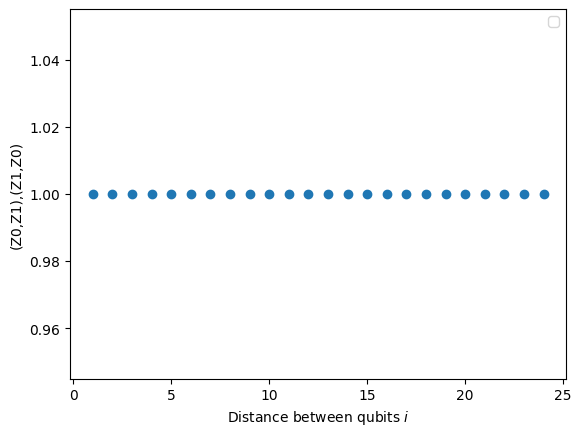

In [25]:
import matplotlib.pyplot as plt

data =list(range(1,len(operators)+1))
results=job.result()[0]
values=results.data.evs
values =[v /values[0] for v in values]

plt.scatter(data,values,marker='o')
plt.xlabel('Distance between qubits $i$')
plt.ylabel('(Z0,Z1),(Z1,Z0)') # line in the video is not understandable
plt.legend()
plt.show()

In [18]:
from qiskit_ibm_runtime import QiskitRuntimeService
from google.colab import userdata

try:
    # Securely retrieve the token from Colab Secrets
    IBM_TOKEN = userdata.get('IBM_QUANTUM_TOKEN')

    # Initialize service with the token
    service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_TOKEN)

    job_id = 'd8bbbv6honmc73cjp2f0'
    job = service.job(job_id)

    print(f"Successfully connected to IBM Quantum and retrieved job {job_id}")
    print(f"Job status: {job.status()}")

except userdata.SecretNotFoundError:
    print("Error: 'IBM_QUANTUM_TOKEN' not found in Colab Secrets (🔑).")
except Exception as e:
    print(f"An error occurred: {e}")

qiskit_runtime_service._discover_account:WARNING:2026-05-28 05:57:57,113: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service._discover_backends_from_instance:WARNING:2026-05-28 06:04:04,404: Invalid instance crn:v1:bluemix:public:quantum-computing:us-east:a/2466fdacd401435fb95817fd68d19219:1bc359b4-1cdc-49a1-9519-58c2658b28b5::
qiskit_runtime_service.__init__:WARNING:2026-05-28 06:04:04,405: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Successfully connected to IBM Quantum and retrieved job d8bbbv6honmc73cjp2f0
Job status: DONE


Plotting 24 points.


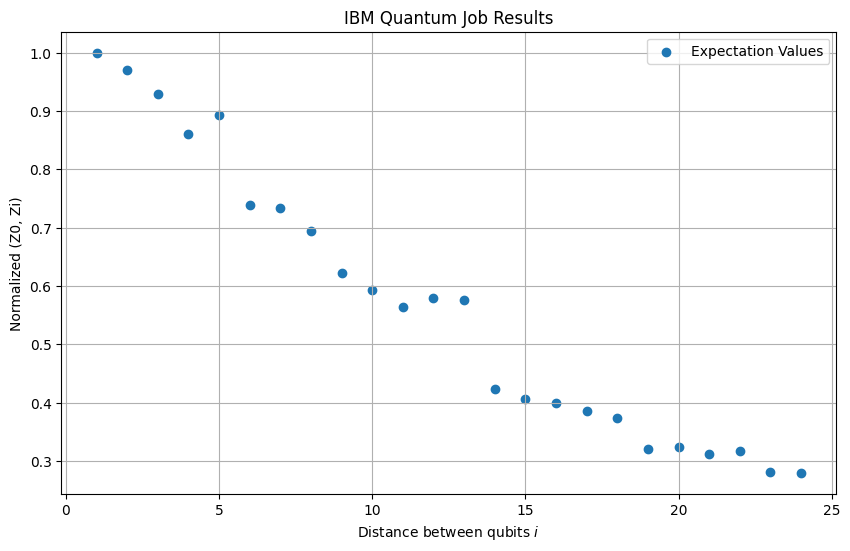

In [20]:
import matplotlib.pyplot as plt

# Get results from the job
results = job.result()[0]
values = results.data.evs

# Normalize values
if len(values) > 0:
    values = [v / values[0] for v in values]

# Create data range matching the actual number of values received
data = list(range(1, len(values) + 1))

print(f"Plotting {len(data)} points.")

plt.figure(figsize=(10, 6))
plt.scatter(data, values, marker='o', label='Expectation Values')
plt.xlabel('Distance between qubits $i$')
plt.ylabel('Normalized (Z0, Zi)')
plt.title('IBM Quantum Job Results')
plt.grid(True)
plt.legend()
plt.show()

### Analysis: QPU vs. CPU Simulation Results

Comparing the results from the `AerSimulator` (CPU) and the IBM Quantum hardware (QPU) reveals key insights into the current state of quantum computing:

1. **Ideal vs. Noisy:** The CPU simulation (Variable `expectation_values`) represents an ideal, noise-free environment where expectation values likely remain near $1.0$. The QPU results (Variable `values`) include real-world noise such as gate errors, readout errors, and decoherence ($T_1$ and $T_2$ times).
2. **Decay with Distance:** In the QPU plot, you may observe a decay in the normalized expectation values as the 'Distance between qubits $i$' increases. This is often due to the cumulative error of the CNOT gates used to create the entanglement chain; more gates generally lead to higher decoherence.
3. **Normalization:** We normalized the QPU results by the first value ($v/values[0]$) to help visualize the relative loss of signal, as the initial state preparation itself often incurs some baseline error.